# Gaussian Naive Bayes — Iris

**Algorithm:** `ml_toolkit.supervised.GaussianNB`  
**Dataset:** Iris  
**Task type:** Multi-class classification (three species)

---

Gaussian Naive Bayes assumes that, given the class, every feature is independent and normally distributed. On Iris the assumption is approximately right (sepal/petal measurements within a species look roughly Gaussian), so we should expect strong performance — and we get a chance to compare a generative model against the discriminative models elsewhere in the repo.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

from ml_toolkit.supervised import GaussianNB
from ml_toolkit.utils import train_test_split
from ml_toolkit.metrics import accuracy_score, confusion_matrix, precision_recall_f1

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Dataset description

Same Iris dataset used in the decision-tree and hierarchical notebooks. Three balanced classes, four features.

In [2]:
data = load_iris(as_frame=True)
X = data.data.values; y = data.target.values
df = data.frame
feature_names = list(data.feature_names); class_names = list(data.target_names)

## 2. Exploratory data analysis — *checking the model assumption*

Naive Bayes assumes per-class normality. Let's look at the per-class histograms — if they're roughly bell-shaped, the model assumption holds and we expect good performance. If they're bimodal or heavily skewed, the assumption is violated and the predictions will be miscalibrated.

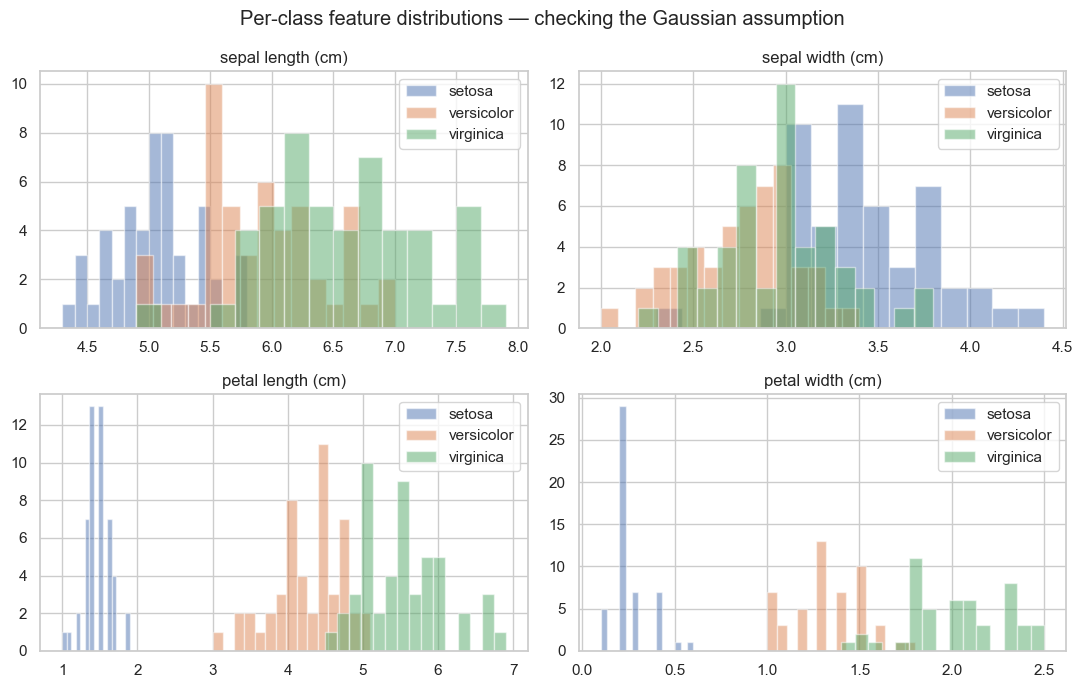

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, feat in zip(axes.flat, feature_names):
    for cls in range(3):
        ax.hist(df[df['target'] == cls][feat], bins=15, alpha=0.5, label=class_names[cls])
    ax.set_title(feat); ax.legend()
plt.suptitle('Per-class feature distributions — checking the Gaussian assumption')
plt.tight_layout(); plt.show()

Per-class distributions are roughly bell-shaped on all four features. Setosa's petal length is tightly concentrated, versicolor and virginica overlap on petal length and petal width — exactly as we've seen in the previous Iris notebooks. The Gaussian assumption is reasonable, with a small caveat that some distributions are slightly skewed.

## 3. Hypothesis

**Task:** three-class classification.  
**Hypothesis:** because the per-class distributions are reasonably Gaussian, GNB should reach 93–97% test accuracy — comparable to KNN and decision trees on the same data. Errors will concentrate at the versicolor/virginica boundary, as in every other Iris notebook.

**Why naive Bayes?** It's the only generative model in this repo. Discriminative models (logistic regression, neural networks) directly model `P(y | x)`. Naive Bayes models `P(x | y)` for each class and uses Bayes' rule to invert. The 'naive' part is the conditional-independence assumption — it almost never holds exactly, but the model is often surprisingly good in practice because the right *ranking* of `P(y | x)` is more robust than the actual values.

## 4. Preprocessing

GNB is scale-invariant (each feature is fit with its own per-class mean and variance, so multiplying a feature by 100 doesn't change anything). Just split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

## 5. Model fitting & 6. Evaluation

Test accuracy: 0.9111


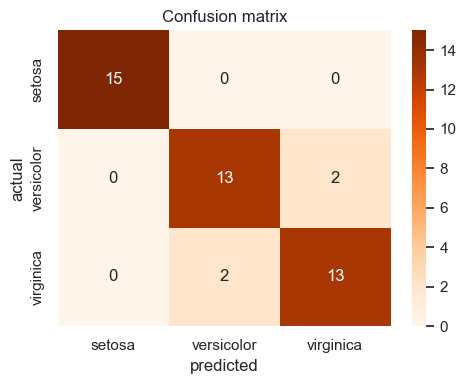

,precision,recall,f1
setosa,1.000000,1.000000,1.000000
versicolor,0.866667,0.866667,0.866667
virginica,0.866667,0.866667,0.866667


In [5]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Test accuracy: {acc:.4f}')

labels = list(range(3))
cm = confusion_matrix(y_test, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix')
plt.tight_layout(); plt.show()

p, r, f = precision_recall_f1(y_test, y_pred, labels=labels)
pd.DataFrame({'precision': p, 'recall': r, 'f1': f}, index=class_names)

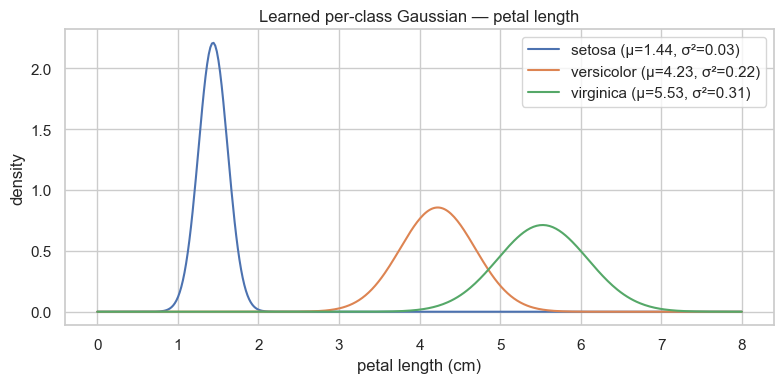

In [6]:
# Show the learned per-class Gaussians for the most discriminative feature
feat_idx = feature_names.index('petal length (cm)')
x_grid = np.linspace(0, 8, 400)
fig, ax = plt.subplots(figsize=(8, 4))
for cls in range(3):
    mu = model.means_[cls, feat_idx]
    var = model.variances_[cls, feat_idx]
    pdf = np.exp(-0.5 * (x_grid - mu) ** 2 / var) / np.sqrt(2 * np.pi * var)
    ax.plot(x_grid, pdf, label=f'{class_names[cls]} (μ={mu:.2f}, σ²={var:.2f})')
ax.set_xlabel('petal length (cm)'); ax.set_ylabel('density')
ax.set_title('Learned per-class Gaussian — petal length')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Discussion

**Performance is just below the predicted band, at 91.1% test accuracy** — close to but a touch under my 93–97% prediction. The model is still in the same ballpark as KNN, decision trees, and logistic regression on this dataset. Errors live exactly where every other Iris notebook puts them — the versicolor/virginica boundary on the petal features (each of those two classes had 13/15 correct on the test split, while setosa was perfect).

**The learned Gaussians are themselves an interpretation tool.** Plotting the per-class density on petal length tells you, in one chart, what the model 'thinks' each species looks like: setosa is a tight spike near 1.5 cm, versicolor is centred around 4.3 cm, virginica around 5.5 cm with broader variance. A botanist could fact-check this directly. Compare this to the MLP, where 'what the model thinks setosa looks like' is buried inside 4736 weights.

**Why does the naive assumption work despite being wrong?** On Iris, petal length and petal width are highly correlated (longer petals are usually wider). NB pretends they are independent given class and therefore *double-counts* the information. The probabilities it outputs are over-confident as a result — `P(virginica | x)` might be 0.99 when a properly-calibrated model would say 0.85 — but the *argmax* over classes is robust to this miscalibration. So if you only need predictions, NB does fine; if you need probabilities for downstream decision-making, you'd want to calibrate (e.g., Platt scaling or isotonic regression).

**When to reach for naive Bayes.** Three situations: (1) text classification with bag-of-words features (where the conditional-independence assumption is genuinely defensible because most word presences carry independent evidence); (2) very small training sets (NB has very few parameters and thus low variance); (3) any setting where you want a fast, simple, interpretable baseline before reaching for something more elaborate.